# 01_02 - Preparação dos preços CEPEA Paranagua

## Objetivo

Limpar, validar e agregar para frequência semanal os preços diários do indicador da Soja

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load de dataframe

In [2]:
data = pd.read_parquet("/content/cepea_paranagua.parquet")

print(data.head())

print(data.tail())

         Data À vista R$ À vista US$
0  04/01/2016      81,64       20,17
1  05/01/2016      82,26       20,61
2  06/01/2016      81,84       20,37
3  07/01/2016      82,35       20,36
4  08/01/2016      83,16       20,61
            Data À vista R$ À vista US$
2592  27/05/2026     129,89       25,67
2593  28/05/2026     130,90       26,02
2594  29/05/2026     130,12       25,79
2595  01/06/2026     130,25       25,98
2596  02/06/2026     128,74       25,68


In [3]:
print(data.columns)

print(data.info())

Index(['Data', 'À vista R$', 'À vista US$'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2597 entries, 0 to 2596
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Data         2597 non-null   object
 1   À vista R$   2597 non-null   object
 2   À vista US$  2597 non-null   object
dtypes: object(3)
memory usage: 61.0+ KB
None


# Alteração de nome das colunas

In [4]:
mapa_colunas = {
    "Data": "data",
    "À vista R$": "preco_rs",
    "À vista US$": "preco_usd",
}

data.rename(columns=mapa_colunas, inplace=True)

print(data.columns)

Index(['data', 'preco_rs', 'preco_usd'], dtype='object')


# Padronizando data ao seu tipo datetime64

In [5]:
data['data'] = pd.to_datetime(data['data'], errors="coerce", dayfirst=True)

print(data.info())

datas_invalidas = data['data'].isna().sum()

print(datas_invalidas)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2597 entries, 0 to 2596
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       2597 non-null   datetime64[ns]
 1   preco_rs   2597 non-null   object        
 2   preco_usd  2597 non-null   object        
dtypes: datetime64[ns](1), object(2)
memory usage: 61.0+ KB
None
0


# Converter preços para float

In [6]:
data['preco_rs'] = data['preco_rs'].str.replace(',', '.').astype(float)
data['preco_usd'] = data['preco_usd'].str.replace(',', '.').astype(float)

print(data.head())

print(data.info)

        data  preco_rs  preco_usd
0 2016-01-04     81.64      20.17
1 2016-01-05     82.26      20.61
2 2016-01-06     81.84      20.37
3 2016-01-07     82.35      20.36
4 2016-01-08     83.16      20.61
<bound method DataFrame.info of            data  preco_rs  preco_usd
0    2016-01-04     81.64      20.17
1    2016-01-05     82.26      20.61
2    2016-01-06     81.84      20.37
3    2016-01-07     82.35      20.36
4    2016-01-08     83.16      20.61
...         ...       ...        ...
2592 2026-05-27    129.89      25.67
2593 2026-05-28    130.90      26.02
2594 2026-05-29    130.12      25.79
2595 2026-06-01    130.25      25.98
2596 2026-06-02    128.74      25.68

[2597 rows x 3 columns]>


In [7]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2597 entries, 0 to 2596
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       2597 non-null   datetime64[ns]
 1   preco_rs   2597 non-null   float64       
 2   preco_usd  2597 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 61.0 KB
None


In [8]:
data.isna().sum()

,0
data,0
preco_rs,0
preco_usd,0


# Cobertura temporal

In [9]:
print("data inicial: ", data['data'].min())
print("data final: ", data['data'].max())
print("quantidade de registros: ", len(data))

data inicial:  2016-01-04 00:00:00
data final:  2026-06-02 00:00:00
quantidade de registros:  2597


# Duplicatas

In [10]:
duplicatas = data.duplicated().sum()

print(duplicatas)

0


# Valores ausentes

In [11]:
print(data.isna().sum())

print(data.isna().mean().mul(100).round(2))

data         0
preco_rs     0
preco_usd    0
dtype: int64
data         0.0
preco_rs     0.0
preco_usd    0.0
dtype: float64


# Valores impossiveis

In [12]:
precos_invalidos_rs = (data['preco_rs'] <= 0).sum()
precos_invalidos_usd = (data['preco_usd'] <= 0).sum()

print(precos_invalidos_rs)
print(precos_invalidos_usd)

0
0


# Estatisticas descritivas

In [13]:
data[['preco_rs', 'preco_usd']].describe()

,preco_rs,preco_usd
count,2597.000000,2597.000000
mean,122.355949,26.051625
std,39.611880,5.062002
min,64.250000,18.110000
25%,82.760000,22.310000
50%,129.340000,24.550000
75%,149.180000,29.590000
max,207.140000,41.280000


# Inspeção visual

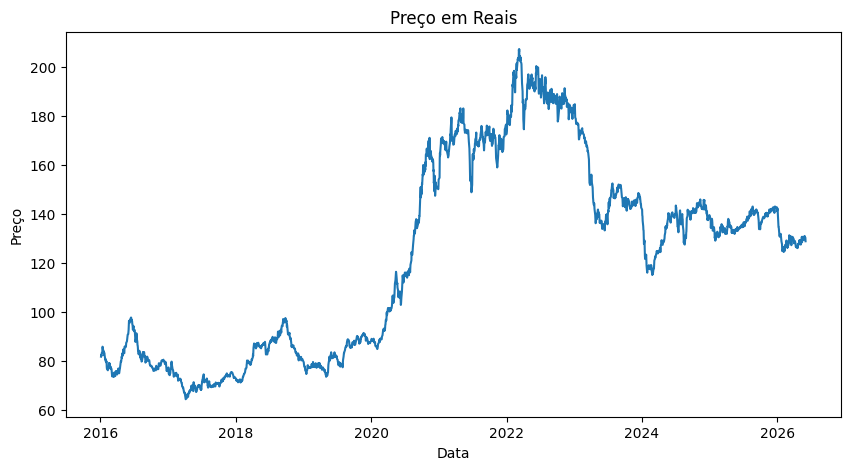

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#preco em reais

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    data["data"],
    data["preco_rs"],
)

ax.set_title("Preço em Reais")
ax.set_xlabel("Data")
ax.set_ylabel("Preço")

plt.show()

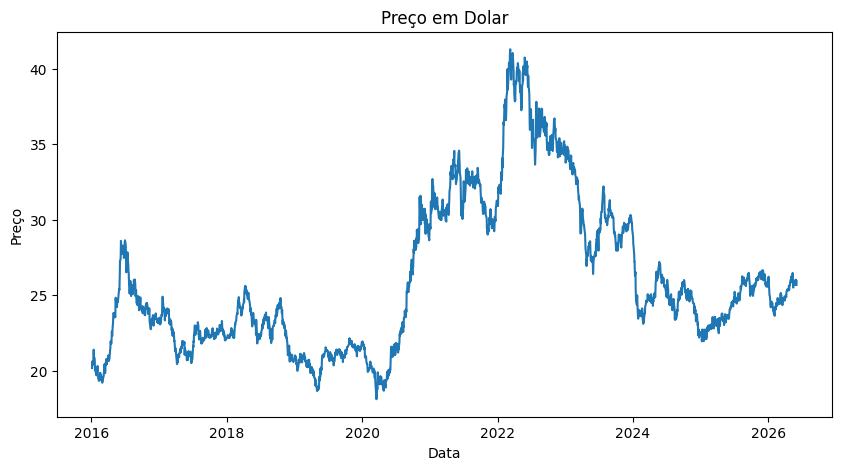

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#preco em dolar

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    data["data"],
    data["preco_usd"],
)

ax.set_title("Preço em Dolar")
ax.set_xlabel("Data")
ax.set_ylabel("Preço")

plt.show()

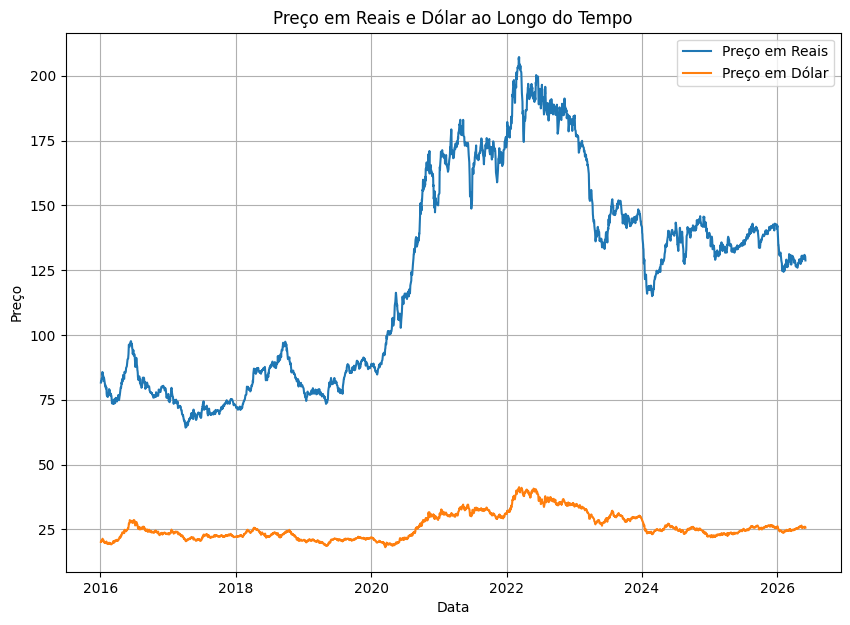

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    data["data"],
    data["preco_rs"],
    label="Preço em Reais"
)

ax.plot(
    data["data"],
    data["preco_usd"],
    label="Preço em Dólar"
)

ax.set_title("Preço em Reais e Dólar ao Longo do Tempo")
ax.set_xlabel("Data")
ax.set_ylabel("Preço")
ax.legend()
ax.grid(True)

plt.show()

# Inspeção de datas

In [17]:
copia_dados = data.copy()
copia_dados.head()

,data,preco_rs,preco_usd
0,2016-01-04,81.64,20.17
1,2016-01-05,82.26,20.61
2,2016-01-06,81.84,20.37
3,2016-01-07,82.35,20.36
4,2016-01-08,83.16,20.61


In [18]:
copia_dados["intervalo_dias"] = (copia_dados["data"].diff().dt.days)

copia_dados["intervalo_dias"].value_counts().sort_index()

copia_dados.nlargest(20, "intervalo_dias")[["data", "intervalo_dias"]]

,data,intervalo_dias
25,2016-02-10,5.0
290,2017-03-01,5.0
498,2018-01-02,5.0
527,2018-02-14,5.0
743,2018-12-26,5.0
746,2019-01-02,5.0
789,2019-03-06,5.0
1034,2020-02-26,5.0
1243,2020-12-28,5.0
1246,2021-01-04,5.0


# Definição de semana

In [19]:
data["semana"] = (data["data"].dt.to_period("W-FRI").dt.end_time.dt.normalize())

print(data.head())

        data  preco_rs  preco_usd     semana
0 2016-01-04     81.64      20.17 2016-01-08
1 2016-01-05     82.26      20.61 2016-01-08
2 2016-01-06     81.84      20.37 2016-01-08
3 2016-01-07     82.35      20.36 2016-01-08
4 2016-01-08     83.16      20.61 2016-01-08


# Agregações semanais

In [20]:
cepea_semanal = (
    data.sort_values('data').groupby('semana', as_index=False)
    .agg(
        preco_rs_minimo=('preco_rs', 'min'),
        preco_rs_maximo=('preco_rs', 'max'),
        preco_rs_media=('preco_rs', 'mean'),
        preco_rs_fechamento=('preco_rs', 'last'),
        preco_usd_minimo=('preco_usd', 'min'),
        preco_usd_maximo=('preco_usd', 'max'),
        preco_usd_media=('preco_usd', 'mean'),
        preco_usd_fechamento=('preco_usd', 'last'),
)
)

cepea_semanal = (cepea_semanal.sort_values('semana').reset_index(drop=True))

cepea_semanal

,semana,preco_rs_minimo,preco_rs_maximo,preco_rs_media,preco_rs_fechamento,preco_usd_minimo,preco_usd_maximo,preco_usd_media,preco_usd_fechamento
0,2016-01-08,81.64,83.16,82.250,83.16,20.17,20.61,20.424,20.61
1,2016-01-15,83.35,85.70,84.822,84.42,20.59,21.39,21.066,20.85
2,2016-01-22,82.39,83.98,83.220,82.94,20.02,20.83,20.344,20.19
3,2016-01-29,79.89,81.49,80.692,79.89,19.70,19.90,19.826,19.85
4,2016-02-05,76.69,79.82,78.588,76.69,19.60,20.31,19.968,19.60
...,...,...,...,...,...,...,...,...,...
539,2026-05-08,127.38,129.14,128.350,127.70,25.88,26.24,26.072,26.09
540,2026-05-15,128.33,130.55,129.280,129.14,25.50,26.47,26.028,25.50
541,2026-05-22,129.25,130.57,129.758,129.62,25.80,25.95,25.878,25.80
542,2026-05-29,129.47,130.90,130.058,130.12,25.67,26.02,25.822,25.79


In [21]:
print(cepea_semanal.head())
print(cepea_semanal.tail())

      semana  preco_rs_minimo  preco_rs_maximo  preco_rs_media  \
0 2016-01-08            81.64            83.16          82.250   
1 2016-01-15            83.35            85.70          84.822   
2 2016-01-22            82.39            83.98          83.220   
3 2016-01-29            79.89            81.49          80.692   
4 2016-02-05            76.69            79.82          78.588   

   preco_rs_fechamento  preco_usd_minimo  preco_usd_maximo  preco_usd_media  \
0                83.16             20.17             20.61           20.424   
1                84.42             20.59             21.39           21.066   
2                82.94             20.02             20.83           20.344   
3                79.89             19.70             19.90           19.826   
4                76.69             19.60             20.31           19.968   

   preco_usd_fechamento  
0                 20.61  
1                 20.85  
2                 20.19  
3                 19.85 

# Validação de tabela semanal

In [22]:
cepea_semanal.head()

,semana,preco_rs_minimo,preco_rs_maximo,preco_rs_media,preco_rs_fechamento,preco_usd_minimo,preco_usd_maximo,preco_usd_media,preco_usd_fechamento
0,2016-01-08,81.64,83.16,82.250,83.16,20.17,20.61,20.424,20.61
1,2016-01-15,83.35,85.70,84.822,84.42,20.59,21.39,21.066,20.85
2,2016-01-22,82.39,83.98,83.220,82.94,20.02,20.83,20.344,20.19
3,2016-01-29,79.89,81.49,80.692,79.89,19.70,19.90,19.826,19.85
4,2016-02-05,76.69,79.82,78.588,76.69,19.60,20.31,19.968,19.60


In [23]:
cepea_semanal.tail()

,semana,preco_rs_minimo,preco_rs_maximo,preco_rs_media,preco_rs_fechamento,preco_usd_minimo,preco_usd_maximo,preco_usd_media,preco_usd_fechamento
539,2026-05-08,127.38,129.14,128.350,127.70,25.88,26.24,26.072,26.09
540,2026-05-15,128.33,130.55,129.280,129.14,25.50,26.47,26.028,25.50
541,2026-05-22,129.25,130.57,129.758,129.62,25.80,25.95,25.878,25.80
542,2026-05-29,129.47,130.90,130.058,130.12,25.67,26.02,25.822,25.79
543,2026-06-05,128.74,130.25,129.495,128.74,25.68,25.98,25.830,25.68


In [24]:
cepea_semanal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544 entries, 0 to 543
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   semana                544 non-null    datetime64[ns]
 1   preco_rs_minimo       544 non-null    float64       
 2   preco_rs_maximo       544 non-null    float64       
 3   preco_rs_media        544 non-null    float64       
 4   preco_rs_fechamento   544 non-null    float64       
 5   preco_usd_minimo      544 non-null    float64       
 6   preco_usd_maximo      544 non-null    float64       
 7   preco_usd_media       544 non-null    float64       
 8   preco_usd_fechamento  544 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 38.4 KB


In [25]:
cepea_semanal.isna().sum()

,0
semana,0
preco_rs_minimo,0
preco_rs_maximo,0
preco_rs_media,0
preco_rs_fechamento,0
preco_usd_minimo,0
preco_usd_maximo,0
preco_usd_media,0
preco_usd_fechamento,0


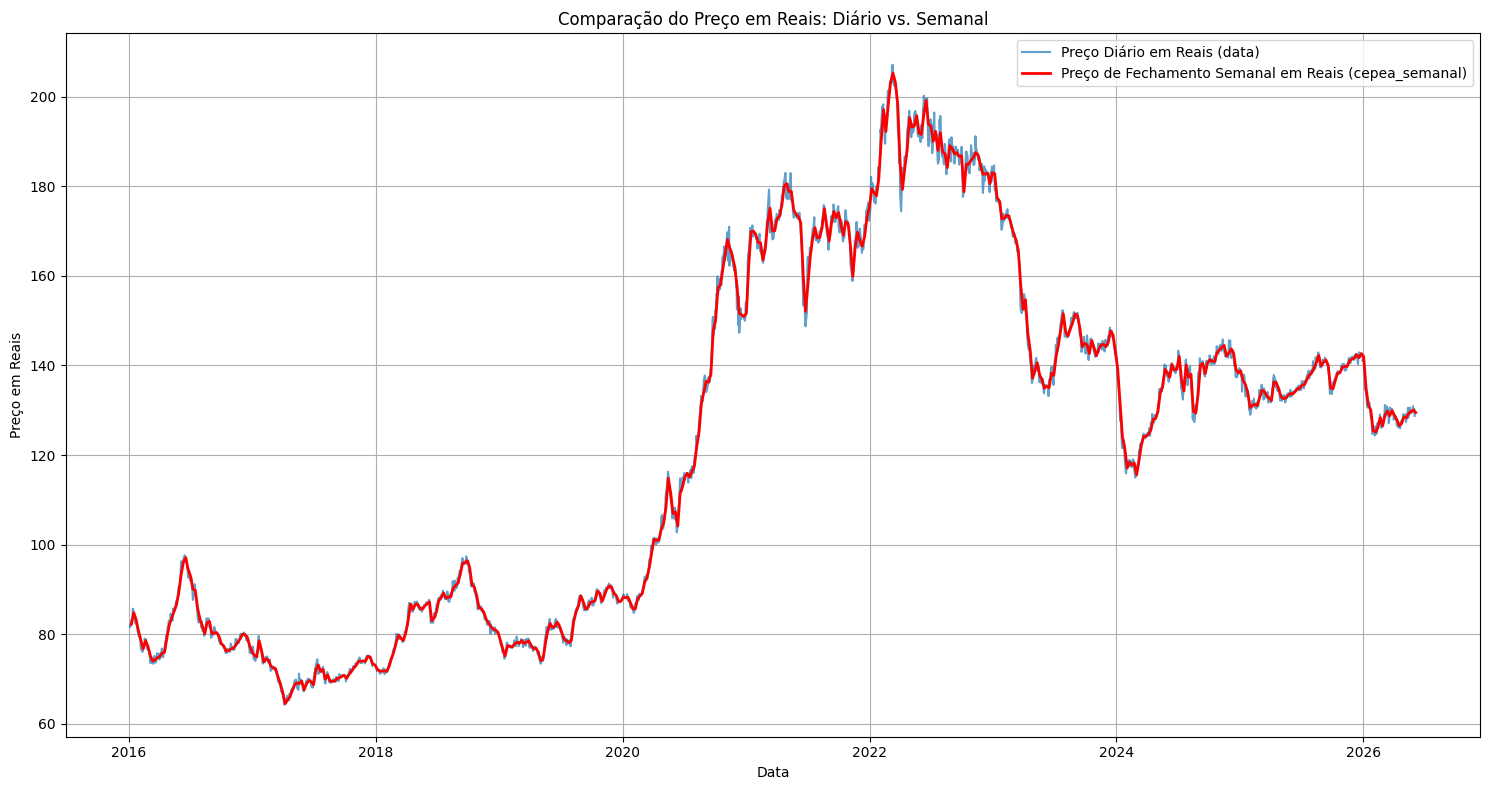

In [26]:
fig, ax = plt.subplots(figsize=(15, 8))

# Plot daily preco_rs
ax.plot(
    data['data'],
    data['preco_rs'],
    label='Preço Diário em Reais (data)',
    alpha=0.7
)

# Plot weekly preco_rs_fechamento
ax.plot(
    cepea_semanal['semana'],
    cepea_semanal['preco_rs_media'],
    label='Preço de Fechamento Semanal em Reais (cepea_semanal)',
    color='red',
    linewidth=2
)

ax.set_title('Comparação do Preço em Reais: Diário vs. Semanal')
ax.set_xlabel('Data')
ax.set_ylabel('Preço em Reais')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [28]:
cepea_semanal.to_parquet("cepea_paranagua_semanal.parquet")